# NSL-KDD Dataset Analysis

Phase 1 exploratory analysis for the OrbitShield capstone project. This notebook is for understanding the data — production preprocessing logic lives in `src/preprocessing/`, not here.

Dataset: NSL-KDD (`KDDTrain+.txt`, `KDDTest+.txt`). See `docs/datasets/dataset_selection.md` for why this dataset was chosen and its satellite-domain limitations.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.loader import load_nsl_kdd, profile_dataframe
from src.data.schema import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, ATTACK_CATEGORY_MAP
from src.preprocessing.labels import add_binary_label

dataset = load_nsl_kdd(REPO_ROOT / "data" / "raw")
train_df = dataset.train
test_df = dataset.test
print(f"KDDTrain+: {train_df.shape}")
print(f"KDDTest+:  {test_df.shape}")

KDDTrain+: (125973, 43)
KDDTest+:  (22544, 43)


## 1. Dataset shape

In [2]:
print("KDDTrain+ shape:", train_df.shape)
print("KDDTest+ shape: ", test_df.shape)
train_df.head()

KDDTrain+ shape: (125973, 43)
KDDTest+ shape:  (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Feature types

In [3]:
print(f"Numerical features ({len(NUMERICAL_COLUMNS)}):", NUMERICAL_COLUMNS)
print(f"Categorical features ({len(CATEGORICAL_COLUMNS)}):", CATEGORICAL_COLUMNS)
train_df.dtypes.value_counts()

Numerical features (38): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Categorical features (3): ['protocol_type', 'service', 'flag']


int64      24
float64    15
str         4
Name: count, dtype: int64

## 3. Missing values

In [4]:
missing = train_df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:", dict(missing) if len(missing) else "none")

Columns with missing values: none


## 4. Duplicate analysis

In [5]:
dupe_count = train_df.duplicated().sum()
print(f"Duplicate rows in KDDTrain+: {dupe_count} ({100 * dupe_count / len(train_df):.2f}%)")

Duplicate rows in KDDTrain+: 0 (0.00%)


## 5. Label distribution

In [6]:
labeled = add_binary_label(train_df, "attack")
print(labeled["label_binary"].value_counts())
print()
print(labeled["label_original"].value_counts())

label_binary
0    67343
1    58630
Name: count, dtype: int64

label_original
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


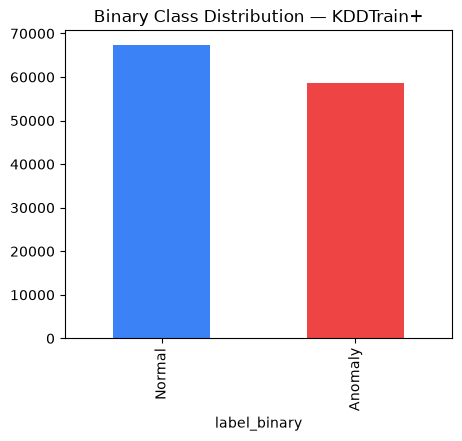

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
labeled["label_binary"].map({0: "Normal", 1: "Anomaly"}).value_counts().plot(kind="bar", ax=ax, color=["#3b82f6", "#ef4444"])
ax.set_title("Binary Class Distribution — KDDTrain+")
plt.show()

## 6. Numerical feature statistics

In [8]:
train_df[NUMERICAL_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


## 7. Visualizations: feature distributions

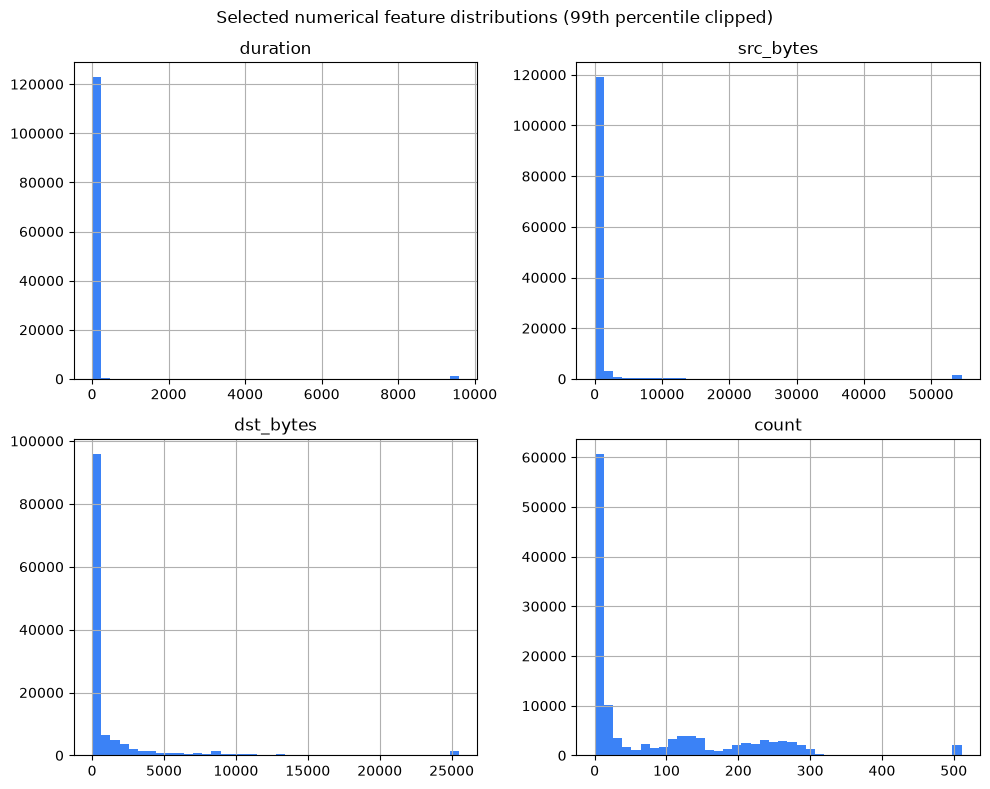

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.flat, ["duration", "src_bytes", "dst_bytes", "count"]):
    train_df[feature].clip(upper=train_df[feature].quantile(0.99)).hist(ax=ax, bins=40, color="#3b82f6")
    ax.set_title(feature)
fig.suptitle("Selected numerical feature distributions (99th percentile clipped)")
fig.tight_layout()
plt.show()

## 8. Attack category breakdown

In [10]:
categories = labeled["label_original"].map(ATTACK_CATEGORY_MAP).fillna("unknown")
print(categories.value_counts())

label_original
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64


## 9. Preprocessing observations

- No missing values were found in the raw NSL-KDD files (both are clean, curated releases).
- No duplicate rows were found within `KDDTrain+` or `KDDTest+` individually.
- Several numerical features (`src_bytes`, `dst_bytes`, `duration`, `count`) are heavily right-skewed with a long tail of extreme values (large transfers/scans) — `StandardScaler` is applied after cleaning; the pipeline does not aggressively winsorize the real data (only these EDA plots clip for visualization).
- `protocol_type`, `service`, and `flag` are nominal categorical columns with no inherent order — one-hot encoded, fit on the training split only.
- The `difficulty` column is excluded from model features (see `docs/datasets/feature_decisions.md`) because it encodes how well *previous* classifiers scored each record, which would leak label-correlated information.
- `KDDTest+` intentionally contains attack types not present in `KDDTrain+` — this is a deliberate part of the original NSL-KDD benchmark design to test generalization, not a data quality problem.

## 10. Conclusions

NSL-KDD is clean enough to preprocess with a straightforward pipeline: no missing-value imputation was actually needed on the real data (the cleaning pipeline still implements it defensively), light infinite-value handling, one-hot encoding for 3 categorical columns, and standard scaling for numerical columns fit on the training split only. The dataset is imbalanced but not extremely so (see `results/reports/dataset_quality.md` for the exact measured ratio). It is a terrestrial IDS dataset, not a satellite dataset — the satellite simulation layer (non-IID partitioning, connectivity/latency/resource constraints) will be built on top of this base traffic in Phase 6, not before.